# 双足步行者（BipedalWalker-v3）强化学习实战：从 A2C 到 PPO

本教程将带你深入探索如何使用 **Stable-Baselines3 (SB3)** 框架，分别使用 **A2C (Advantage Actor-Critic)** 和 **PPO (Proximal Policy Optimization)** 算法来训练一个连续控制领域的经典任务——双足机器人行走（BipedalWalker-v3）。

### 学习目标
1. 了解 `BipedalWalker-v3` 环境的状态空间、动作空间及奖励机制。
2. 掌握 A2C 算法在连续控制任务中的配置与训练，并理解其在高维空间中不稳定的痛点。
3. 掌握 PPO 算法的裁剪（Clipping）机制如何解决更新幅度过大的问题，并实现高效稳定的训练。
4. 对比两种算法的训练表现与收敛稳定性。

## 1. 环境准备与依赖安装

在开始之前，我们需要安装 `gymnasium` 及其 `box2d` 物理引擎底座，以及强化学习标准库 `stable-baselines3`。

In [ ]:
# 安装必要的依赖（如果在本地运行，请取消注释并执行）
# !pip install gymnasium[box2d] stable-baselines3 swig

## 2. 探索 BipedalWalker-v3 环境

BipedalWalker-v3 是一个高维连续控制环境：
- **状态空间 (Observation Space): 24 维**。包含躯干的角度、角速度、水平/垂直速度、两条腿的关节角度与角速度、脚底接触地面的状态以及 10 维激光雷达测距数据（用于探测前方地形）。
- **动作空间 (Action Space): 4 维连续向量**。分别对应：腿1髋关节扭矩、腿1膝关节扭矩、腿2髋关节扭矩、腿2膝关节扭矩。取值范围均在 `[-1, 1]` 之间。
- **解决标准 (Solved Standard)**：连续 100 个回合的平均奖励 $\ge 300$ 分。

In [1]:
import gymnasium as gym
import numpy as np

# 创建环境并查看维度
env = gym.make("BipedalWalker-v3")
print(f"状态空间维度: {env.observation_space.shape}")
print(f"动作空间维度: {env.action_space.shape}")
print(f"动作范围高值: {env.action_space.high}")
print(f"动作范围低值: {env.action_space.low}")

# 测试随机策略基线
sim_rewards = []
for episode in range(5):
    obs, _ = env.reset(seed=episode)
    total_reward = 0
    while True:
        action = env.action_space.sample() # 随机采样动作
        obs, reward, terminated, truncated, _ = env.step(action)
        total_reward += reward
        if terminated or truncated:
            break
    sim_rewards.append(total_reward)

print(f"随机策略平均回报: {np.mean(sim_rewards):.2f} (通常在 -100 左右，因为机器人一启动就会摔倒并触发 -100 惩罚)")
env.close()

e:\anaconda3\envs\rl-course\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


状态空间维度: (24,)
动作空间维度: (4,)
动作范围高值: [1. 1. 1. 1.]
动作范围低值: [-1. -1. -1. -1.]
随机策略平均回报: -106.98 (通常在 -100 左右，因为机器人一启动就会摔倒并触发 -100 惩罚)


## 3. 算法一：A2C (Advantage Actor-Critic) 训练

A2C 是一种同步、On-Policy 的 Actor-Critic 架构。在处理类似 BipedalWalker 的多关节协调任务时，A2C 的核心痛点是**每次策略更新缺乏约束**。
如果某次采集的数据质量较差，单次剧烈的梯度更新可能会彻底破坏已经学到的步态，导致损失函数出现剧烈的 Spike（激增），奖励曲线像过山车一样震荡。

为了提升吞吐量和稳定性，我们配置了 16 个并行环境，并将网络拓扑增大至 `[128, 128]`。

**Actor-Critic总损失函数**

总损失由策略损失、价值损失和熵损失加权组合而成，其数学公式如下：
$$TotalLoss = PolicyLoss + (vf\_coef \times ValueLoss) + (ent\_coef \times EntropyLoss)$$

**1. PolicyLoss（策略损失）**

- **计算公式**：通常是 $-Advantage \times \log(Probability)$
- **核心作用**：负责让 Actor 增加好动作的概率，减少坏动作的概率。
- 下面设置vf\_coef是让价值损失拟合慢一点。如果Critic拟合过快，会让Advantage过小，以至于PolicyLoss很小而无法调整Actor的策略

**2. ValueLoss（价值损失）**

- **计算公式**：通常是 $MSE(V(s), Return)$
- **核心作用**：负责让 Critic 的预测值 $V(s)$ 逼近真实的回报 $Return$。

**3. EntropyLoss（熵损失）**

- **核心作用**：鼓励探索，防止策略过早收敛。

In [2]:
from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.evaluation import evaluate_policy
import os

# 创建保存目录
log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)

# 1. 使用 16 个并行环境加速 Rollout
vec_env_a2c = make_vec_env(
    "BipedalWalker-v3", n_envs=16,
    monitor_dir=os.path.join(log_dir, "a2c_monitor")  # 保存每个回合的原始回报
)

# 2. 初始化 A2C 模型
a2c_model = A2C(
    policy="MlpPolicy",
    env=vec_env_a2c,
    learning_rate=7e-4,          # 经典 A2C 学习率
    n_steps=32,                  # 每次环境中各采集 32 步进行一次更新
    gamma=0.99,                  # 折扣因子
    gae_lambda=0.95,             # GAE 因子 计算机GAE的时候远处的奖励会按照0.95的权重进行衰减
    vf_coef=0.5,                 # 价值损失权重
    max_grad_norm=0.5,           # 梯度裁剪防梯度爆炸
    policy_kwargs=dict(net_arch=dict(pi=[128, 128], vf=[128, 128])), # 在构建神经网络时，把“动作决策”和“价值评估”分开处理，并且各自使用两层、每层128个神经元的隐藏层。
    tensorboard_log=os.path.join(log_dir, "a2c_tensorboard"),
    verbose=1
)

# 3. 开始训练 (提示: 完整跑通建议 2M~3M 步，这里演示先设为 100k 步观察状态)
print("开始训练 A2C 模型...")
a2c_model.learn(total_timesteps=100000, tb_log_name="A2C_run", log_interval=1)

# 保存模型
a2c_model.save("a2c_bipedalwalker_100k")
print("A2C 100k 阶段训练完成并保存！")

Using cuda device
开始训练 A2C 模型...
Logging to ./logs/a2c_tensorboard\A2C_run_1


e:\anaconda3\envs\rl-course\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 416      |
|    ep_rew_mean        | -106     |
| time/                 |          |
|    fps                | 1982     |
|    iterations         | 100      |
|    time_elapsed       | 25       |
|    total_timesteps    | 51200    |
| train/                |          |
|    entropy_loss       | -5.61    |
|    explained_variance | 0.955    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -0.219   |
|    std                | 0.984    |
|    value_loss         | 0.0468   |
------------------------------------
A2C 100k 阶段训练完成并保存！


## 4. 算法二：PPO (Proximal Policy Optimization) 训练

PPO 引入了**信任域裁剪（Trust Region Clipping）**机制。它限制了新旧策略的比值（Ratio）不能超过 $[1-\epsilon, 1+\epsilon]$（通常 $\epsilon=0.2$）。
这样可以确保即使收集到了极端的轨迹数据，策略分布的移动（KL散度）也会被控制在安全范围内，从而极大缓解了 A2C 训练中容易出现的“猝死/策略彻底崩溃”问题。

上面max_grad_norm=0.5， 这里梯度的大小教育大小必须控制在0.5以内

In [3]:
from stable_baselines3 import PPO

# 1. 同样创建并行环境（PPO 通常对 Batch 规模要求更高）
vec_env_ppo = make_vec_env(
    "BipedalWalker-v3", n_envs=8,
    monitor_dir=os.path.join(log_dir, "ppo_monitor")  # 保存每个回合的原始回报
)

# 2. 初始化 PPO 模型
ppo_model = PPO(
    policy="MlpPolicy",
    env=vec_env_ppo,
    learning_rate=3e-4,          # PPO 常用较小学习率配合裁剪
    n_steps=2048,                # 每次收集更多样本以保证梯度估计的准确性
    batch_size=64,               # 每次小批量更新的样本量
    n_epochs=10,                 # 同一批数据重复训练次数
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,              # 核心机制：策略裁剪比率
    policy_kwargs=dict(net_arch=dict(pi=[128, 128], vf=[128, 128])),
    tensorboard_log=os.path.join(log_dir, "ppo_tensorboard"),
    verbose=1
)

# 3. 开始训练 PPO
print("开始训练 PPO 模型...")
ppo_model.learn(total_timesteps=100000, tb_log_name="PPO_run", log_interval=1)

# 保存模型
ppo_model.save("ppo_bipedalwalker_100k")
print("PPO 100k 阶段训练完成并保存！")

Using cuda device
开始训练 PPO 模型...
Logging to ./logs/ppo_tensorboard\PPO_run_1


e:\anaconda3\envs\rl-course\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 579      |
|    ep_rew_mean     | -108     |
| time/              |          |
|    fps             | 1501     |
|    iterations      | 1        |
|    time_elapsed    | 10       |
|    total_timesteps | 16384    |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 533         |
|    ep_rew_mean          | -110        |
| time/                   |             |
|    fps                  | 727         |
|    iterations           | 2           |
|    time_elapsed         | 45          |
|    total_timesteps      | 32768       |
| train/                  |             |
|    approx_kl            | 0.006437014 |
|    clip_fraction        | 0.0685      |
|    clip_range           | 0.2         |
|    entropy_loss         | -5.68       |
|    explained_variance   | -0.00391    |
|    learning_rate        | 0.

## 5. 模型对比与评估

训练完成后，我们使用独立的单进程测试环境对两个模型进行多回合（例如 20 回合）的平均奖励评估，对比它们的平均回报（Mean Reward）与表现标准差（Standard Deviation）。

In [4]:
# 创建独立的评估专用环境
eval_env = gym.make("BipedalWalker-v3")

print("------ 评估 A2C 模型 ------")
mean_reward_a2c, std_reward_a2c = evaluate_policy(a2c_model, eval_env, n_eval_episodes=20, deterministic=True)
print(f"A2C 平均得分: {mean_reward_a2c:.2f} +/- {std_reward_a2c:.2f}")

print("\n------ 评估 PPO 模型 ------")
mean_reward_ppo, std_reward_ppo = evaluate_policy(ppo_model, eval_env, n_eval_episodes=20, deterministic=True)
print(f"PPO 平均得分: {mean_reward_ppo:.2f} +/- {std_reward_ppo:.2f}")

eval_env.close()

------ 评估 A2C 模型 ------


e:\anaconda3\envs\rl-course\lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


A2C 平均得分: -111.84 +/- 14.70

------ 评估 PPO 模型 ------
PPO 平均得分: -32.86 +/- 2.27


## 6. 核心指标解读与调参指南

在深入运行代码后，你可以通过启动 TensorBoard 来监控关键训练指标：
```bash
tensorboard --logdir ./logs/
```

### 关键指标对比与排查表：
1. **`loss/policy_loss` (策略损失)**：
   - **A2C**：由于没有截断，若某一步突增（Spike），通常代表策略剧烈震荡。
   - **PPO**：由于存在 `clip_range`，损失波动应当在一个温和范围内。如果长期接近 0，说明策略可能已经过早收敛或陷入死局。
2. **`loss/value_loss` (价值损失)**：
   - 如果该指标持续高企，意味着 Critic 网络无法准确估算当前状态的长期期望回报，应当增加 `n_steps` 让每次 rollout 收集更多样本，或调整 `vf_coef`。
3. **`loss/entropy_loss` (策略熵)**：
   - 熵代表探索度。训练前期熵较高是正常现象。如果动作空间策略熵迅速归零，而平均奖励仍处于低位（例如 -100），说明模型**过早收敛（Early Convergence）**。此时需要通过增大 `ent_coef`（熵系数）来强制其加强探索。
4. **训练演进三阶段的表现**：
   - **早期 (~100k 步)**：模型首先学会“不摔倒”。机器人学会了在原地晃动或维持静态动态平衡，每回合能撑满上限步数，但几乎不往前走，回报多为负值。
   - **中期 (~500k 步)**：跨越双模态行为阈值。同一模型在某些回合能歪歪扭扭走一长段拿 100+ 分，某些回合则迅速摔倒拿 -100 分。此时标准差最大。
   - **后期 (2M 步+)**：动作流畅协调，形成高效步态。PPO 模型通常能做到连续高位收敛（280+），而 A2C 即使走到后期，依然有一定概率由于策略未约束更新而偶然产生摔倒行为。

In [6]:
import os
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

# 设置中文字体，防止图表中的中文显示为方块
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS'] 
plt.rcParams['axes.unicode_minus'] = False 

# ================= 1. 定义读取日志的辅助函数 =================
def extract_tensorboard_data(log_dir, tag):
    """
    从指定的 tensorboard 文件夹中提取指定 tag 的数据
    返回: steps (列表), values (列表)
    """
    # 找到目录下的 event 文件
    event_files = [os.path.join(log_dir, f) for f in os.listdir(log_dir) if 'events.out.tfevents' in f]
    if not event_files:
        print(f"警告：在 {log_dir} 中没有找到 tfevents 日志文件！")
        return [], []
    
    # 假设只有一个 event 文件，或者取最新的一个
    event_file = event_files[0]
    
    # 加载日志，不做截断限制（size_guidance=0 表示全部读取）
    ea = EventAccumulator(event_file, size_guidance={'scalars': 0})
    ea.Reload()
    
    # 检查我们要找的 tag 是否存在
    if tag in ea.Tags()['scalars']:
        events = ea.Scalars(tag)
        steps = [e.step for e in events]
        values = [e.value for e in events]
        return steps, values
    else:
        print(f"警告：在 {log_dir} 中没有找到指标 '{tag}'！")
        return [], []

# ================= 2. 自动定位日志路径 =================
base_log_dir = "./logs/"

# 寻找最新的 A2C 和 PPO 运行文件夹 (根据你的代码 tb_log_name 应该叫 A2C_run_1, PPO_run_1 等)
a2c_dirs = sorted([d for d in os.listdir(base_log_dir) if "A2C_run" in d])
ppo_dirs = sorted([d for d in os.listdir(base_log_dir) if "PPO_run" in d])

if not a2c_dirs or not ppo_dirs:
    print("错误：没有在 ./logs/ 目录下找到对应的 A2C_run 或 PPO_run 文件夹。请确认你已经成功运行了训练代码。")
else:
    a2c_log_path = os.path.join(base_log_dir, a2c_dirs[-1]) # 取最新的一次运行
    ppo_log_path = os.path.join(base_log_dir, ppo_dirs[-1])
    
    print(f"正在读取 A2C 日志: {a2c_log_path}")
    print(f"正在读取 PPO 日志: {ppo_log_path}")

    # ================= 3. 提取真实数据 =================
    # 注意：Stable-Baselines3 中 A2C 和 PPO 的 policy loss 标签名称略有不同
    a2c_steps, a2c_policy_loss = extract_tensorboard_data(a2c_log_path, 'train/policy_loss')
    ppo_steps, ppo_policy_loss = extract_tensorboard_data(ppo_log_path, 'train/policy_gradient_loss')
    
    _, a2c_value_loss = extract_tensorboard_data(a2c_log_path, 'train/value_loss')
    _, ppo_value_loss = extract_tensorboard_data(ppo_log_path, 'train/value_loss')
    
    _, a2c_entropy_loss = extract_tensorboard_data(a2c_log_path, 'train/entropy_loss')
    _, ppo_entropy_loss = extract_tensorboard_data(ppo_log_path, 'train/entropy_loss')

    # ================= 4. 开始绘制图表 =================
    fig, axs = plt.subplots(3, 1, figsize=(12, 14))

    # --- 子图 1: 策略损失 ---
    if a2c_policy_loss and ppo_policy_loss:
        axs[0].plot(a2c_steps, a2c_policy_loss, label=f'A2C Policy Loss', color='red', alpha=0.7)
        axs[0].plot(ppo_steps, ppo_policy_loss, label=f'PPO Policy Loss', color='blue', alpha=0.9)
        axs[0].set_title('1. 真实策略损失 (Policy Loss) 对比', fontsize=14)
        axs[0].set_ylabel('Loss')
        axs[0].legend()
        axs[0].grid(True, linestyle='--', alpha=0.6)

    # --- 子图 2: 价值损失 ---
    if a2c_value_loss and ppo_value_loss:
        axs[1].plot(a2c_steps, a2c_value_loss, label=f'A2C Value Loss', color='orange', alpha=0.8)
        axs[1].plot(ppo_steps, ppo_value_loss, label=f'PPO Value Loss', color='green', alpha=0.9)
        axs[1].set_title('2. 真实价值损失 (Value Loss) 对比', fontsize=14)
        axs[1].set_ylabel('Loss')
        axs[1].legend()
        axs[1].grid(True, linestyle='--', alpha=0.6)

    # --- 子图 3: 策略熵 ---
    if a2c_entropy_loss and ppo_entropy_loss:
        axs[2].plot(a2c_steps, a2c_entropy_loss, label=f'A2C Entropy Loss', color='purple', alpha=0.7)
        axs[2].plot(ppo_steps, ppo_entropy_loss, label=f'PPO Entropy Loss', color='teal', alpha=0.9)
        axs[2].set_title('3. 真实策略熵 (Entropy) 对比', fontsize=14)
        axs[2].set_xlabel('训练步数 (Timesteps)')
        axs[2].set_ylabel('Entropy')
        axs[2].legend()
        axs[2].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

错误：没有在 ./logs/ 目录下找到对应的 A2C_run 或 PPO_run 文件夹。请确认你已经成功运行了训练代码。


A2C 日志：E:\Code\StudyLLM\13. Hands on RL项目\logs\a2c_tensorboard\A2C_run_1
PPO 日志：E:\Code\StudyLLM\13. Hands on RL项目\logs\ppo_tensorboard\PPO_run_1
A2C 可用指标： ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/policy_loss', 'train/std', 'train/value_loss']
PPO 可用指标： ['rollout/ep_len_mean', 'rollout/ep_rew_mean', 'time/fps', 'train/approx_kl', 'train/clip_fraction', 'train/clip_range', 'train/entropy_loss', 'train/explained_variance', 'train/learning_rate', 'train/loss', 'train/policy_gradient_loss', 'train/std', 'train/value_loss']


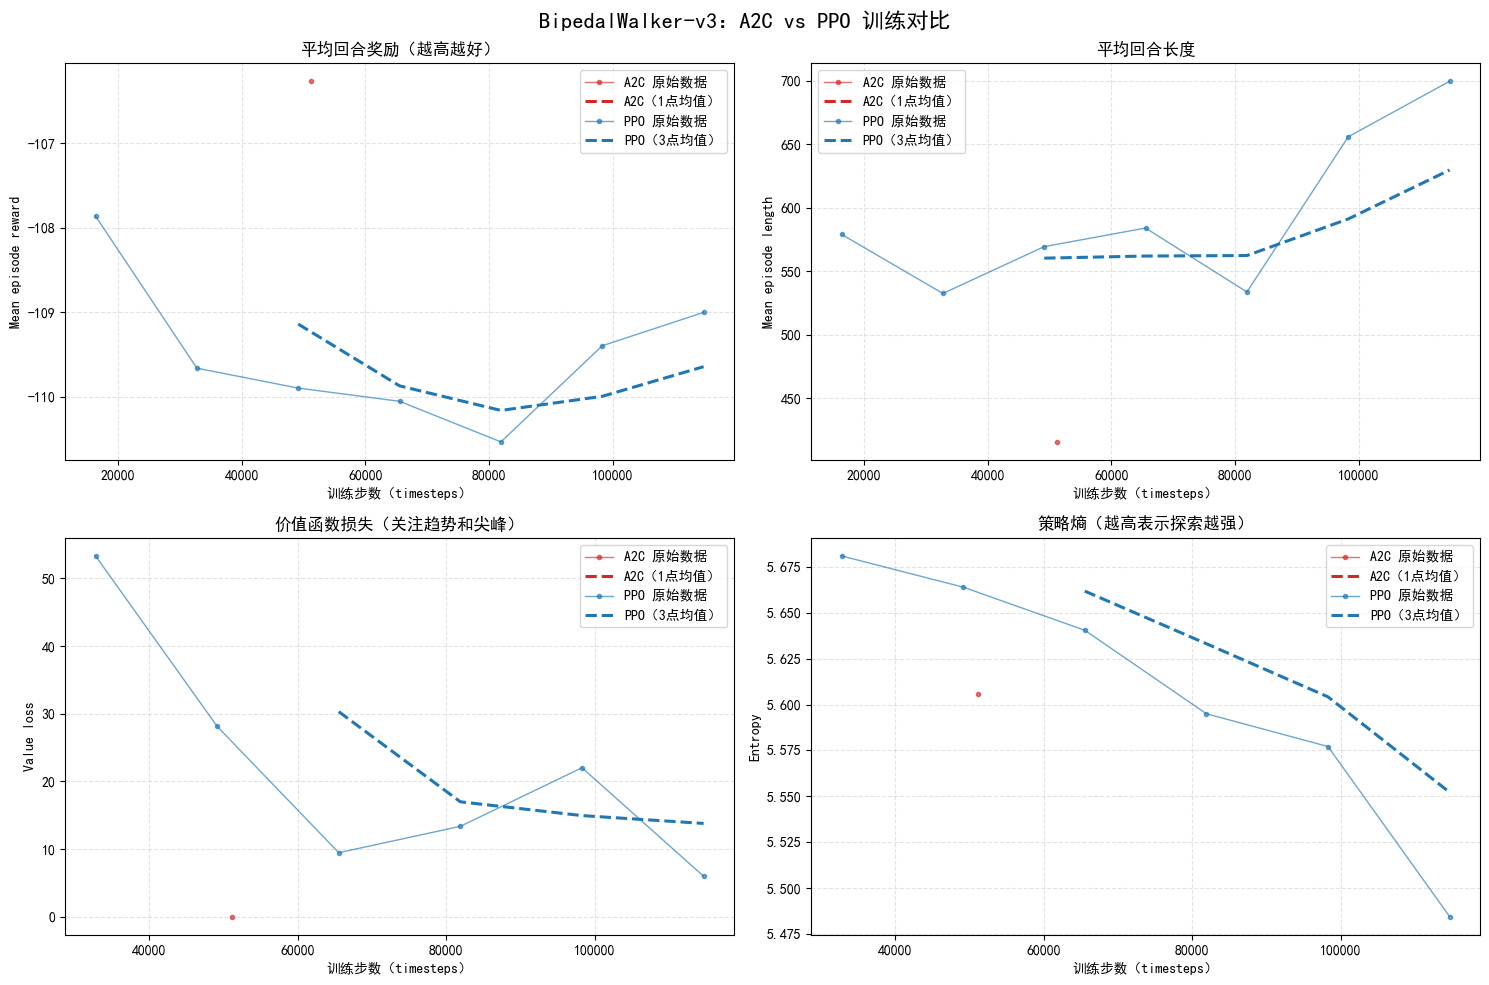

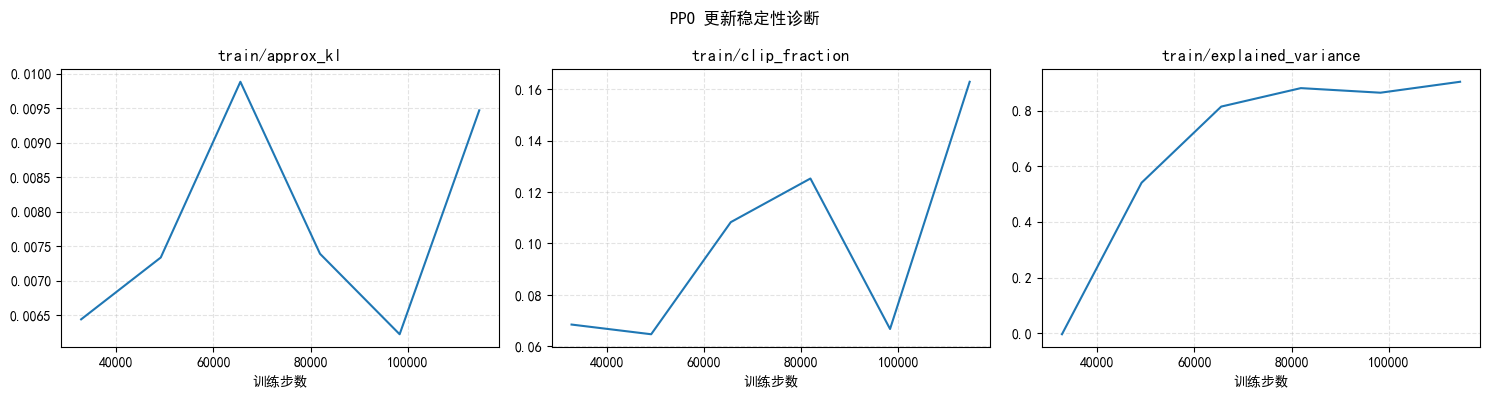


===== 奖励汇总（基于 TensorBoard 的 rollout/ep_rew_mean）=====
A2C: 记录点=1, 最后步数=51200, 末段均值=-106.26, 历史最好=-106.26, 末段标准差=0.00
PPO: 记录点=7, 最后步数=114688, 末段均值=-109.49, 历史最好=-107.86, 末段标准差=0.80

当前至少一个算法少于 3 个奖励记录点，数据不足以可靠比较趋势和稳定性。
请用上方 log_interval=1 的训练代码重新训练，然后再次运行本单元。

没有找到原始回合 Monitor 数据。
请重新运行已加入 monitor_dir 参数的 A2C、PPO 训练单元，再运行本单元。


In [9]:
# 推荐使用这一版进行 A2C / PPO 日志对比（会自动寻找最新一次 run）
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

def find_log_root():
    """兼容从 notebook 所在目录或项目根目录启动 Jupyter 的情况。"""
    candidates = [Path.cwd() / 'logs']
    candidates.extend(p.parent for p in Path.cwd().rglob('a2c_tensorboard'))
    for root in candidates:
        if (root / 'a2c_tensorboard').exists() and (root / 'ppo_tensorboard').exists():
            return root.resolve()
    raise FileNotFoundError('没有找到同时包含 a2c_tensorboard 和 ppo_tensorboard 的 logs 目录。')

def latest_run(parent, run_prefix):
    """取最近修改且确实包含 tfevents 文件的运行目录。"""
    runs = [p for p in parent.glob(f'{run_prefix}*')
            if p.is_dir() and any(p.glob('events.out.tfevents.*'))]
    if not runs:
        raise FileNotFoundError(f'{parent} 下没有找到 {run_prefix}* 日志。')
    return max(runs, key=lambda p: max(f.stat().st_mtime for f in p.glob('events.out.tfevents.*')))

def load_run(run_dir):
    """读取一个 run 的全部标量；返回 {tag: (steps, values)}。"""
    ea = EventAccumulator(str(run_dir), size_guidance={'scalars': 0})
    ea.Reload()
    result = {}
    for tag in ea.Tags().get('scalars', []):
        events = ea.Scalars(tag)
        # 多个 event 文件续训时可能产生重复 step：保留同一步最后写入的值
        by_step = {e.step: e.value for e in events}
        steps = np.array(sorted(by_step), dtype=int)
        result[tag] = (steps, np.array([by_step[s] for s in steps], dtype=float))
    return result

def moving_average(values, window=3):
    if len(values) == 0:
        return values
    window = min(window, len(values))
    return np.convolve(values, np.ones(window) / window, mode='valid')

def plot_pair(ax, a2c_data, ppo_data, tag, title, ylabel, smooth_window=3, negate=False):
    found = False
    for name, data, color in [('A2C', a2c_data, 'tab:red'), ('PPO', ppo_data, 'tab:blue')]:
        if tag not in data:
            continue
        steps, values = data[tag]
        if negate:
            values = -values  # SB3 的 entropy_loss 是负熵，取负后更直观
        if len(values) == 0:
            continue
        found = True
        ax.plot(steps, values, color=color, alpha=0.65, linewidth=1, marker='o',
                markersize=3, label=f'{name} 原始数据')
        avg = moving_average(values, smooth_window)
        avg_steps = steps[len(steps) - len(avg):]
        if smooth_window > 1:
            ax.plot(avg_steps, avg, color=color, linewidth=2.2, linestyle='--',
                    label=f'{name}（{min(smooth_window, len(values))}点均值）')
    ax.set_title(title)
    ax.set_xlabel('训练步数（timesteps）')
    ax.set_ylabel(ylabel)
    ax.grid(True, linestyle='--', alpha=0.35)
    if found:
        ax.legend()
    else:
        ax.text(0.5, 0.5, f'日志中暂无 {tag}', ha='center', va='center', transform=ax.transAxes)

log_root = find_log_root()
a2c_run = latest_run(log_root / 'a2c_tensorboard', 'A2C_run')
ppo_run = latest_run(log_root / 'ppo_tensorboard', 'PPO_run')
print(f'A2C 日志：{a2c_run}')
print(f'PPO 日志：{ppo_run}')

a2c_data = load_run(a2c_run)
ppo_data = load_run(ppo_run)
print('A2C 可用指标：', sorted(a2c_data))
print('PPO 可用指标：', sorted(ppo_data))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_pair(axes[0, 0], a2c_data, ppo_data, 'rollout/ep_rew_mean',
          '平均回合奖励（越高越好）', 'Mean episode reward')
plot_pair(axes[0, 1], a2c_data, ppo_data, 'rollout/ep_len_mean',
          '平均回合长度', 'Mean episode length')
plot_pair(axes[1, 0], a2c_data, ppo_data, 'train/value_loss',
          '价值函数损失（关注趋势和尖峰）', 'Value loss')
plot_pair(axes[1, 1], a2c_data, ppo_data, 'train/entropy_loss',
          '策略熵（越高表示探索越强）', 'Entropy', negate=True)
fig.suptitle('BipedalWalker-v3：A2C vs PPO 训练对比', fontsize=16)
fig.tight_layout()
plt.show()

# PPO 独有诊断：approx_kl 越大代表策略单次更新越激进；clip_fraction 表示被裁剪样本占比
ppo_diagnostic_tags = ['train/approx_kl', 'train/clip_fraction', 'train/explained_variance']
available = [tag for tag in ppo_diagnostic_tags if tag in ppo_data]
if available:
    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4), squeeze=False)
    for ax, tag in zip(axes[0], available):
        steps, values = ppo_data[tag]
        ax.plot(steps, values, color='tab:blue')
        ax.set_title(tag)
        ax.set_xlabel('训练步数')
        ax.grid(True, linestyle='--', alpha=0.35)
    fig.suptitle('PPO 更新稳定性诊断')
    fig.tight_layout()
    plt.show()

def reward_summary(name, data, tail_points=10):
    tag = 'rollout/ep_rew_mean'
    if tag not in data or len(data[tag][1]) == 0:
        return {'算法': name, '记录点数': 0, '最后步数': np.nan,
                '末段平均奖励': np.nan, '最好平均奖励': np.nan, '末段波动': np.nan}
    steps, rewards = data[tag]
    tail = rewards[-min(tail_points, len(rewards)):]
    return {'算法': name, '记录点数': len(rewards), '最后步数': int(steps[-1]),
            '末段平均奖励': float(np.mean(tail)), '最好平均奖励': float(np.max(rewards)),
            '末段波动': float(np.std(tail))}

summaries = [reward_summary('A2C', a2c_data), reward_summary('PPO', ppo_data)]
print('\n===== 奖励汇总（基于 TensorBoard 的 rollout/ep_rew_mean）=====')
for s in summaries:
    print(f"{s['算法']}: 记录点={s['记录点数']}, 最后步数={s['最后步数']}, "
          f"末段均值={s['末段平均奖励']:.2f}, 历史最好={s['最好平均奖励']:.2f}, "
          f"末段标准差={s['末段波动']:.2f}")

valid = [s for s in summaries if s['记录点数'] >= 3]
if len(valid) == 2:
    better = max(valid, key=lambda s: s['末段平均奖励'])
    steadier = min(valid, key=lambda s: s['末段波动'])
    print(f"\n自动结论：当前日志中 {better['算法']} 的末段奖励更高；"
          f"{steadier['算法']} 的末段奖励波动更小。")
    print('注意：loss 的绝对大小不能直接判定算法优劣，最终应以相同步数下的奖励曲线和独立评估结果为准。')
else:
    print('\n当前至少一个算法少于 3 个奖励记录点，数据不足以可靠比较趋势和稳定性。')
    print('请用上方 log_interval=1 的训练代码重新训练，然后再次运行本单元。')

# ================= 按回合绘制原始回报 + 50 回合滑动平均 =================
# 注意：原始回报来自 make_vec_env(..., monitor_dir=...) 生成的 *.monitor.csv。
import json
import pandas as pd

def load_monitor_rewards(monitor_dir):
    """合并所有并行环境的 Monitor 文件，并按回合实际结束时间排序。"""
    records = []
    for csv_path in Path(monitor_dir).glob('*.monitor.csv'):
        with csv_path.open('r', encoding='utf-8') as f:
            first_line = f.readline().strip()
        try:
            t_start = float(json.loads(first_line[1:]).get('t_start', 0))
        except (json.JSONDecodeError, ValueError):
            t_start = 0.0
        df = pd.read_csv(csv_path, comment='#')
        if {'r', 't'}.issubset(df.columns):
            for reward, elapsed in zip(df['r'], df['t']):
                records.append((t_start + float(elapsed), float(reward)))
    records.sort(key=lambda item: item[0])
    return np.array([reward for _, reward in records], dtype=float)

def plot_episode_rewards(ax, rewards, algorithm, window=50):
    episodes = np.arange(1, len(rewards) + 1)
    rolling = pd.Series(rewards).rolling(window=window, min_periods=1).mean().to_numpy()
    ax.plot(episodes, rewards, color='#90caf9', alpha=0.45, linewidth=0.8,
            label='原始回报')
    ax.plot(episodes, rolling, color='#1565c0', linewidth=2.4,
            label=f'{window} 回合滑动平均')
    ax.axhline(300, color='#66a96b', linestyle='--', linewidth=1.8, label='solved (300)')
    ax.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.6)
    ax.set_title(f'{algorithm} BipedalWalker-v3 回合奖励', fontsize=15)
    ax.set_xlabel('回合')
    ax.set_ylabel('累计奖励')
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left')

monitor_sets = [
    ('A2C', log_root / 'a2c_monitor'),
    ('PPO', log_root / 'ppo_monitor'),
]
loaded_rewards = [(name, load_monitor_rewards(path)) for name, path in monitor_sets]
available_rewards = [(name, rewards) for name, rewards in loaded_rewards if len(rewards) > 0]

if available_rewards:
    fig, axes = plt.subplots(len(available_rewards), 1,
                             figsize=(15, 6 * len(available_rewards)), squeeze=False)
    for ax, (name, rewards) in zip(axes[:, 0], available_rewards):
        plot_episode_rewards(ax, rewards, name, window=50)
        print(f'{name}: 已读取 {len(rewards)} 个原始回合回报')
    fig.tight_layout()
    plt.show()
else:
    print('\n没有找到原始回合 Monitor 数据。')
    print('请重新运行已加入 monitor_dir 参数的 A2C、PPO 训练单元，再运行本单元。')
